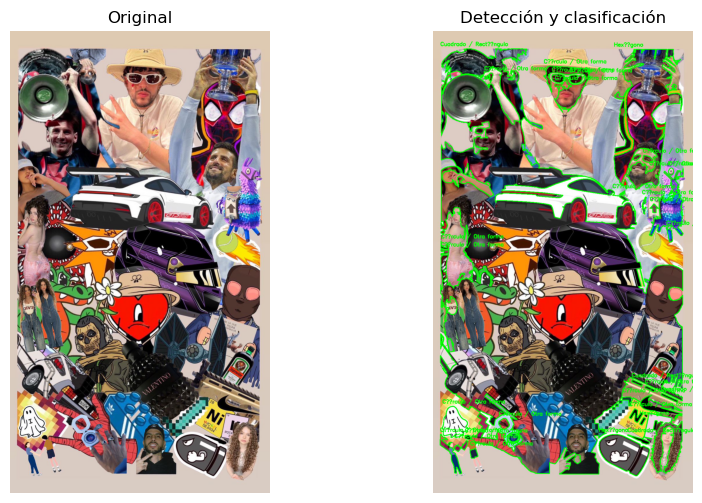

[{'clasificacion': 'Círculo / Otra forma', 'vertices': 7, 'area': 658, 'hu_moments': [0.7685988914018497, 2.7958765445605773, 4.629205191649818, 7.314008161392288, -11.995612821484123, -8.749127888313248, -11.978479796476206]}, {'clasificacion': 'Círculo / Otra forma', 'vertices': 10, 'area': 641, 'hu_moments': [0.4096672701214509, 1.0742278105018703, 2.0372034666912806, 2.8797909050242185, 6.6541258819532825, -3.7826966067305885, 5.338795667689275]}, {'clasificacion': 'Círculo / Otra forma', 'vertices': 8, 'area': 210, 'hu_moments': [0.7606859405703041, 2.523235253832425, 3.271750587015935, 4.932907781347613, -9.068608918306069, -6.227693896358015, -9.45412001135502]}, {'clasificacion': 'Cuadrado / Rectángulo', 'vertices': 4, 'area': 611, 'hu_moments': [0.18848824142209275, 0.4128513267645509, 1.1418003542544062, 1.200274310081959, 2.3713156063518217, 1.4067532098751196, 4.740613502472176]}, {'clasificacion': 'Hexágono', 'vertices': 6, 'area': 16076, 'hu_moments': [0.7407875413591314,

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def clasificar_por_vertices(approx):
    vertices = len(approx)
    if vertices == 3:
        return "Triángulo"
    elif vertices == 4:
        return "Cuadrado / Rectángulo"
    elif vertices == 5:
        return "Pentágono"
    elif vertices == 6:
        return "Hexágono"
    else:
        return "Círculo / Otra forma"

def detectar_figuras_y_momentos(ruta_imagen):
    img = cv2.imread(ruta_imagen)
    if img is None:
        raise FileNotFoundError(f"No se encontró la imagen: {ruta_imagen}")

    gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binaria = cv2.threshold(gris, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    salida = img.copy()
    resultados = []

    for contorno in contornos:
        area = cv2.contourArea(contorno)
        if area < 200:  # ignora pequeños ruidos
            continue

        perimetro = cv2.arcLength(contorno, True)
        approx = cv2.approxPolyDP(contorno, 0.02 * perimetro, True)
        clasificacion = clasificar_por_vertices(approx)

        momentos = cv2.moments(contorno)
        hu = cv2.HuMoments(momentos).flatten()
        hu_log = -np.sign(hu) * np.log10(np.abs(hu) + 1e-12)

        cv2.drawContours(salida, [contorno], -1, (0, 255, 0), 2)
        x, y, w, h = cv2.boundingRect(contorno)
        cv2.putText(salida, clasificacion, (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        resultados.append({
            "clasificacion": clasificacion,
            "vertices": len(approx),
            "area": int(area),
            "hu_moments": hu_log.tolist()
        })

    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Detección y clasificación")
    plt.imshow(cv2.cvtColor(salida, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

    return resultados


resultados = detectar_figuras_y_momentos("fondazo.jpg")
print(resultados)